<a href="https://colab.research.google.com/github/vishnuvardhan1699/2520030392_ML/blob/main/Practical/week%2010/DBSCAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DBSCAN Clustering
Number of Clusters: 9
Noise Points: 2706
Silhouette Score: -0.045


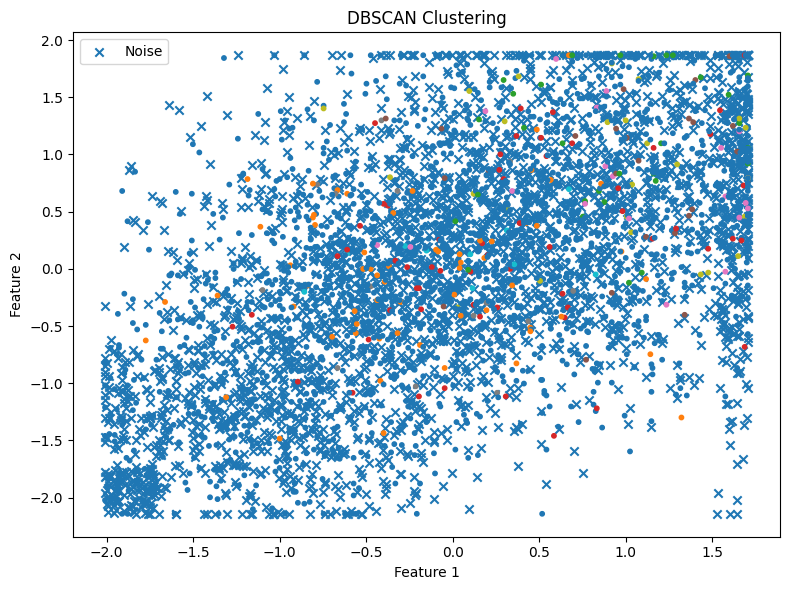

DBSCAN completed successfully.


In [2]:
# DBSCAN.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42

NUMERIC_COLS = [
    "CGPA", "AttendancePercent", "Internships", "Projects", "Workshops",
    "Certifications", "Publications", "AptitudeTestScore",
    "SoftSkillsRating", "CodingTestScore", "MockInterviewScore"
]

CATEGORICAL_COLS = [
    "Gender", "City", "CollegeTier", "Stream", "Specialisation",
    "Hostel", "HistoryOfBacklogs", "ExtraCurricular"
]

df = pd.read_csv("/content/placement_predict_50k Dataset (1).csv")

imputer = SimpleImputer(strategy="median")

num_df = pd.DataFrame(
    imputer.fit_transform(df[NUMERIC_COLS]),
    columns=NUMERIC_COLS
)

cat_df = pd.get_dummies(
    df[CATEGORICAL_COLS],
    drop_first=True
)

feature_df = pd.concat(
    [num_df, cat_df],
    axis=1
)

scaler = StandardScaler()
X = scaler.fit_transform(feature_df)

np.random.seed(RANDOM_STATE)

sample_idx = np.random.choice(
    len(X),
    5000,
    replace=False
)

X_sample = X[sample_idx]

dbscan = DBSCAN(
    eps=4.0,
    min_samples=15
)

labels = dbscan.fit_predict(X_sample)

clusters = set(labels)

n_clusters = len(
    clusters - {-1}
)

n_noise = np.sum(
    labels == -1
)

print("DBSCAN Clustering")
print("Number of Clusters:", n_clusters)
print("Noise Points:", n_noise)

mask = labels != -1

if len(set(labels[mask])) >= 2:
    score = silhouette_score(
        X_sample[mask],
        labels[mask]
    )

    print(
        "Silhouette Score:",
        round(score, 3)
    )

plt.figure(figsize=(8, 6))

plt.scatter(
    X_sample[~mask, 0],
    X_sample[~mask, 1],
    marker="x",
    label="Noise"
)

plt.scatter(
    X_sample[mask, 0],
    X_sample[mask, 1],
    c=labels[mask],
    cmap="tab10",
    s=10
)

plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

plt.tight_layout()
plt.savefig("dbscan_clusters.png")
plt.show()

print("DBSCAN completed successfully.")